# MVTec AD — PatchCore cho toàn bộ category

Pipeline cho mỗi category:
1. Trích patch feature (WideResNet50 layer2 + layer3) từ ảnh `train/good`
2. Chọn coreset bằng k-center greedy → memory bank
3. Đánh giá trên `test`: image-level AUROC, pixel-level AUROC, threshold tốt nhất theo F1
4. Lưu checkpoint `<category>.pt`

In [1]:
import gc
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from IPython.display import FileLink, display
from PIL import Image
from sklearn.metrics import f1_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import Wide_ResNet50_2_Weights, wide_resnet50_2


DATASET_ROOT = Path("/kaggle/input/datasets/ipythonx/mvtec-ad")
WORKING_DIR = Path("/kaggle/working")
CHECKPOINT_DIR = WORKING_DIR / "patchcore_checkpoints"
ZIP_BASE_PATH = WORKING_DIR / "patchcore_checkpoints"

IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

FEATURE_LAYERS = ("layer2", "layer3")
TRAIN_BATCH_SIZE = 32
TEST_BATCH_SIZE = 8
NUM_WORKERS = 2
CANDIDATE_SIZE = 20000
CORESET_SIZE = 5000
SEED = 42

# Bỏ qua category đã có checkpoint -> chạy lại notebook sẽ tiếp tục từ chỗ bị ngắt
SKIP_EXISTING = True

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Dataset

In [2]:
def list_images(directory):
    return sorted(
        p for p in Path(directory).rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def discover_categories(dataset_root):
    return sorted(
        d.name for d in dataset_root.iterdir()
        if (d / "train" / "good").is_dir()
    )


CATEGORIES = discover_categories(DATASET_ROOT)

print(f"Found {len(CATEGORIES)} categories: {CATEGORIES}")

Found 15 categories: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [3]:
def summarize_category(category):
    category_dir = DATASET_ROOT / category
    test_dir = category_dir / "test"

    defect_types = sorted(
        d.name for d in test_dir.iterdir()
        if d.is_dir() and d.name != "good"
    )

    return {
        "category": category,
        "train_good": len(list_images(category_dir / "train" / "good")),
        "test_good": len(list_images(test_dir / "good")),
        "test_defect": sum(len(list_images(test_dir / t)) for t in defect_types),
        "defect_types": ", ".join(defect_types),
    }


dataset_summary = pd.DataFrame([summarize_category(c) for c in CATEGORIES])
dataset_summary

,category,train_good,test_good,test_defect,defect_types
0,bottle,209,20,63,"broken_large, broken_small, contamination"
1,cable,224,58,92,"bent_wire, cable_swap, combined, cut_inner_ins..."
2,capsule,219,23,109,"crack, faulty_imprint, poke, scratch, squeeze"
3,carpet,280,28,89,"color, cut, hole, metal_contamination, thread"
4,grid,264,21,57,"bent, broken, glue, metal_contamination, thread"
5,hazelnut,391,40,70,"crack, cut, hole, print"
6,leather,245,32,92,"color, cut, fold, glue, poke"
7,metal_nut,220,22,93,"bent, color, flip, scratch"
8,pill,267,26,141,"color, combined, contamination, crack, faulty_..."
9,screw,320,41,119,"manipulated_front, scratch_head, scratch_neck,..."


In [4]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class ImageFolderDataset(Dataset):
    """Trả về (image, path) cho mọi ảnh trong thư mục (đệ quy)."""

    def __init__(self, root, transform):
        self.images = list_images(root)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]
        image = Image.open(path).convert("RGB")

        return self.transform(image), str(path)


def make_loader(root, batch_size):
    return DataLoader(
        ImageFolderDataset(root, transform),
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=device.type == "cuda",
    )

## Backbone & feature extraction

In [5]:
def load_backbone(device):
    backbone = wide_resnet50_2(weights=Wide_ResNet50_2_Weights.DEFAULT)
    backbone = backbone.to(device).eval()

    for param in backbone.parameters():
        param.requires_grad = False

    return backbone


backbone = load_backbone(device)

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-9ba9bcbe.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-9ba9bcbe.pth


100%|██████████| 263M/263M [00:01<00:00, 213MB/s]  


In [6]:
def make_output_hook(features, layer_name):
    def hook(module, inputs, output):
        features[layer_name] = output

    return hook


def capture_layer_outputs(images, backbone, device):
    features = {}

    handles = [
        getattr(backbone, name).register_forward_hook(make_output_hook(features, name))
        for name in FEATURE_LAYERS
    ]

    try:
        with torch.no_grad():
            backbone(images.to(device))
    finally:
        for handle in handles:
            handle.remove()

    return [features[name] for name in FEATURE_LAYERS]


def extract_features(images, backbone, device):
    """
    images: [B, 3, H, W]

    return:
        patches: [B, h*w, C] (L2-normalized)
        feature_size: (h, w)
    """
    layer2, layer3 = capture_layer_outputs(images, backbone, device)

    # Resize layer3 -> same spatial size as layer2
    layer3 = F.interpolate(
        layer3,
        size=layer2.shape[-2:],
        mode="bilinear",
        align_corners=False,
    )

    # [B, 512, 28, 28] + [B, 1024, 28, 28] -> [B, 1536, 28, 28]
    combined = torch.cat([layer2, layer3], dim=1)

    B, C, H, W = combined.shape

    # [B, C, H, W] -> [B, H*W, C]
    patches = combined.permute(0, 2, 3, 1).reshape(B, H * W, C)
    patches = F.normalize(patches, p=2, dim=-1)

    return patches, (H, W)

## Memory bank (coreset)

In [7]:
def kcenter_greedy(features, k):
    """
    features: [N, D]
    k: number of samples to select

    return:
        selected_features: [k, D]
    """
    N = features.shape[0]

    selected_indices = [torch.randint(0, N, (1,)).item()]

    # Khoảng cách từ mỗi point tới selected point gần nhất
    distances = torch.full((N,), float("inf"), device=features.device)

    for _ in range(k - 1):
        latest = features[selected_indices[-1]]

        dist = torch.sum((features - latest) ** 2, dim=1)
        distances = torch.minimum(distances, dist)

        # Chọn point xa nhất
        selected_indices.append(torch.argmax(distances).item())

    return features[torch.tensor(selected_indices, device=features.device)]


def collect_patch_features(loader, backbone, device):
    batches = []

    for images, _ in loader:
        patches, _ = extract_features(images, backbone, device)
        batches.append(patches.reshape(-1, patches.shape[-1]).cpu())

    return torch.cat(batches, dim=0)


def subsample_coreset(features, device):
    candidate_count = min(CANDIDATE_SIZE, len(features))
    candidates = features[torch.randperm(len(features))[:candidate_count]].to(device)

    coreset = kcenter_greedy(candidates, k=min(CORESET_SIZE, candidate_count))

    return coreset.cpu()


def build_memory_bank(category, backbone, device):
    loader = make_loader(DATASET_ROOT / category / "train" / "good", TRAIN_BATCH_SIZE)
    features = collect_patch_features(loader, backbone, device)

    print(f"  patch features: {tuple(features.shape)}")

    return subsample_coreset(features, device)

## Inference

In [8]:
def predict_batch(images, backbone, memory_bank, device):
    """
    memory_bank: [N, D], đã nằm trên device

    return:
        scores: [B] image-level anomaly score
        anomaly_maps: [B, *IMAGE_SIZE]
    """
    patches, (h, w) = extract_features(images, backbone, device)

    batch_size, num_patches, dim = patches.shape

    # Khoảng cách tới normal patch gần nhất: [B, h*w]
    nearest = torch.cdist(patches.reshape(-1, dim), memory_bank).min(dim=1).values
    nearest = nearest.reshape(batch_size, num_patches)

    scores = nearest.max(dim=1).values

    anomaly_maps = F.interpolate(
        nearest.reshape(batch_size, 1, h, w),
        size=IMAGE_SIZE,
        mode="bilinear",
        align_corners=False,
    ).squeeze(1)

    return scores.cpu(), anomaly_maps.cpu()


def label_from_path(path):
    # .../test/good/xxx.png -> 0, .../test/<defect>/xxx.png -> 1
    return 0 if Path(path).parent.name == "good" else 1


def run_inference(category, backbone, memory_bank, device):
    loader = make_loader(DATASET_ROOT / category / "test", TEST_BATCH_SIZE)

    scores, anomaly_maps, paths = [], [], []

    for images, batch_paths in loader:
        batch_scores, batch_maps = predict_batch(images, backbone, memory_bank, device)

        scores.append(batch_scores)
        anomaly_maps.append(batch_maps)
        paths.extend(batch_paths)

    return {
        "scores": torch.cat(scores).numpy(),
        "anomaly_maps": torch.cat(anomaly_maps).numpy(),
        "labels": np.array([label_from_path(p) for p in paths]),
        "paths": paths,
    }

## Evaluation

In [9]:
def get_ground_truth_mask(image_path, gt_root):
    image_path = Path(image_path)
    defect_type = image_path.parent.name

    # Good image không có defect mask
    if defect_type == "good":
        return np.zeros(IMAGE_SIZE, dtype=np.uint8)

    # 000.png -> 000_mask.png
    gt_path = Path(gt_root) / defect_type / f"{image_path.stem}_mask{image_path.suffix}"

    if not gt_path.exists():
        raise FileNotFoundError(f"Ground truth not found: {gt_path}")

    # PIL resize nhận (width, height)
    mask = Image.open(gt_path).convert("L").resize(IMAGE_SIZE[::-1], Image.NEAREST)

    return (np.array(mask) > 0).astype(np.uint8)


def find_best_threshold(scores, labels):
    best_threshold, best_f1 = None, -1.0

    for threshold in np.linspace(scores.min(), scores.max(), 100):
        f1 = f1_score(labels, (scores >= threshold).astype(int))

        if f1 > best_f1:
            best_threshold, best_f1 = threshold, f1

    return float(best_threshold), float(best_f1)


def compute_pixel_auroc(paths, anomaly_maps, gt_root):
    gt_masks = np.stack([get_ground_truth_mask(p, gt_root) for p in paths])

    return float(roc_auc_score(gt_masks.ravel(), anomaly_maps.ravel()))


def evaluate(result, gt_root):
    best_threshold, best_f1 = find_best_threshold(result["scores"], result["labels"])

    return {
        "image_auroc": float(roc_auc_score(result["labels"], result["scores"])),
        "pixel_auroc": compute_pixel_auroc(result["paths"], result["anomaly_maps"], gt_root),
        "best_threshold": best_threshold,
        "best_f1": best_f1,
    }

## Checkpoint

In [10]:
def checkpoint_path(category):
    return CHECKPOINT_DIR / f"{category}.pt"


def save_checkpoint(category, memory_bank, metrics):
    torch.save(
        {
            "category": category,
            # float16 giảm 1/2 dung lượng file; feature đã L2-normalize nên mất mát không đáng kể
            "memory_bank": memory_bank.cpu().half(),
            "threshold": metrics["best_threshold"],
            "metrics": metrics,
            "config": {
                "backbone": "wide_resnet50_2",
                "feature_layers": list(FEATURE_LAYERS),
                "image_size": list(IMAGE_SIZE),
                "mean": IMAGENET_MEAN,
                "std": IMAGENET_STD,
            },
        },
        checkpoint_path(category),
    )


def load_checkpoint(category, device):
    checkpoint = torch.load(checkpoint_path(category), map_location="cpu")
    checkpoint["memory_bank"] = checkpoint["memory_bank"].float().to(device)

    return checkpoint

## Train + evaluate tất cả category

In [11]:
def process_category(category, backbone, device):
    torch.manual_seed(SEED)

    memory_bank = build_memory_bank(category, backbone, device).to(device)
    result = run_inference(category, backbone, memory_bank, device)
    metrics = evaluate(result, DATASET_ROOT / category / "ground_truth")

    save_checkpoint(category, memory_bank, metrics)

    return metrics


def release_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def fetch_or_compute_metrics(category, backbone, device):
    if SKIP_EXISTING and checkpoint_path(category).exists():
        print(f"[skip] {category}: checkpoint đã tồn tại")
        return torch.load(checkpoint_path(category), map_location="cpu")["metrics"]

    print(f"[train] {category}")
    metrics = process_category(category, backbone, device)
    release_memory()

    return metrics

In [12]:
all_metrics = []

for index, category in enumerate(CATEGORIES, start=1):
    print(f"({index}/{len(CATEGORIES)})", end=" ")

    metrics = fetch_or_compute_metrics(category, backbone, device)
    all_metrics.append({"category": category, **metrics})

    print(
        f"  image AUROC: {metrics['image_auroc']:.4f} | "
        f"pixel AUROC: {metrics['pixel_auroc']:.4f} | "
        f"F1: {metrics['best_f1']:.4f}"
    )

(1/15) [train] bottle
  patch features: (163856, 1536)
  image AUROC: 1.0000 | pixel AUROC: 0.9865 | F1: 1.0000
(2/15) [train] cable
  patch features: (175616, 1536)
  image AUROC: 0.9794 | pixel AUROC: 0.9756 | F1: 0.9418
(3/15) [train] capsule
  patch features: (171696, 1536)
  image AUROC: 0.8939 | pixel AUROC: 0.9730 | F1: 0.9515
(4/15) [train] carpet
  patch features: (219520, 1536)
  image AUROC: 0.9956 | pixel AUROC: 0.9902 | F1: 0.9829
(5/15) [train] grid
  patch features: (206976, 1536)
  image AUROC: 0.8981 | pixel AUROC: 0.9750 | F1: 0.8972
(6/15) [train] hazelnut
  patch features: (306544, 1536)
  image AUROC: 0.9982 | pixel AUROC: 0.9888 | F1: 0.9859
(7/15) [train] leather
  patch features: (192080, 1536)
  image AUROC: 1.0000 | pixel AUROC: 0.9931 | F1: 1.0000
(8/15) [train] metal_nut
  patch features: (172480, 1536)
  image AUROC: 1.0000 | pixel AUROC: 0.9695 | F1: 1.0000
(9/15) [train] pill
  patch features: (209328, 1536)
  image AUROC: 0.9602 | pixel AUROC: 0.9557 | F

## Kết quả

In [13]:
results_df = pd.DataFrame(all_metrics).set_index("category")
results_df.loc["mean"] = results_df.mean(numeric_only=True)

results_df.to_csv(CHECKPOINT_DIR / "results.csv")

results_df.round(4)

,image_auroc,pixel_auroc,best_threshold,best_f1
category,,,,
bottle,1.0000,0.9865,0.6394,1.0000
cable,0.9794,0.9756,0.7047,0.9418
capsule,0.8939,0.9730,0.5211,0.9515
carpet,0.9956,0.9902,0.5836,0.9829
grid,0.8981,0.9750,0.6454,0.8972
hazelnut,0.9982,0.9888,0.7678,0.9859
leather,1.0000,0.9931,0.5928,1.0000
metal_nut,1.0000,0.9695,0.6773,1.0000
pill,0.9602,0.9557,0.6085,0.9580


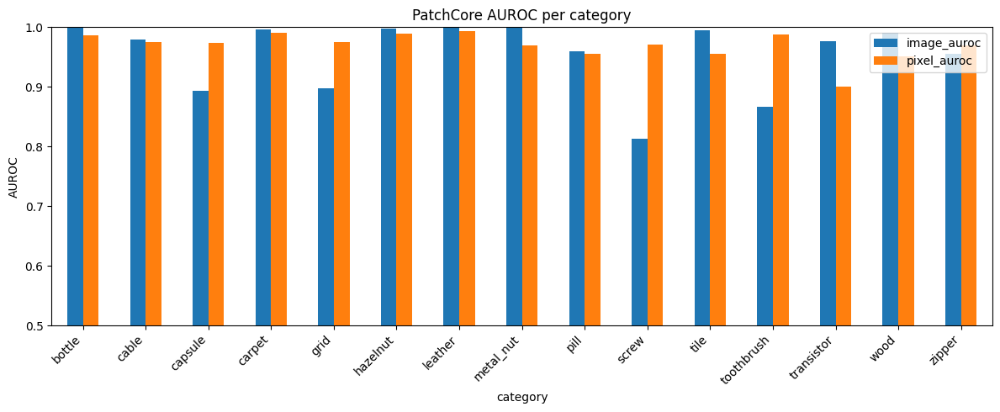

In [14]:
per_category = results_df.drop(index="mean")

ax = per_category[["image_auroc", "pixel_auroc"]].plot.bar(figsize=(12, 5))
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("AUROC")
ax.set_title("PatchCore AUROC per category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Nén checkpoint để tải về

In [15]:
zip_path = Path(shutil.make_archive(str(ZIP_BASE_PATH), "zip", root_dir=CHECKPOINT_DIR))

print(f"Zip: {zip_path} ({zip_path.stat().st_size / 1024**2:.1f} MB)")
print("Files:", sorted(p.name for p in CHECKPOINT_DIR.iterdir()))

# Link tải trực tiếp (đường dẫn tương đối với /kaggle/working)
display(FileLink(zip_path.name))

Zip: /kaggle/working/patchcore_checkpoints.zip (135.0 MB)
Files: ['bottle.pt', 'cable.pt', 'capsule.pt', 'carpet.pt', 'grid.pt', 'hazelnut.pt', 'leather.pt', 'metal_nut.pt', 'pill.pt', 'results.csv', 'screw.pt', 'tile.pt', 'toothbrush.pt', 'transistor.pt', 'wood.pt', 'zipper.pt']


/kaggle/working/patchcore_checkpoints.zip

## (Tuỳ chọn) Kiểm tra checkpoint đã lưu

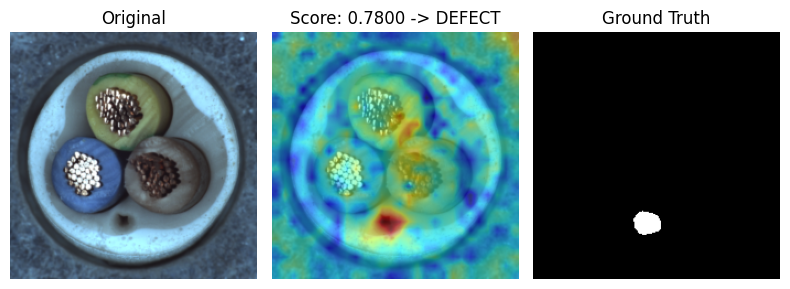

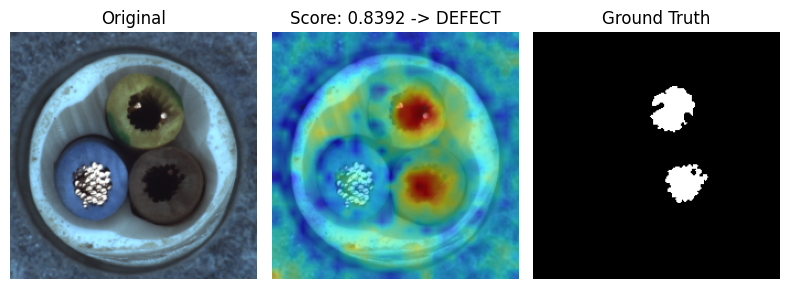

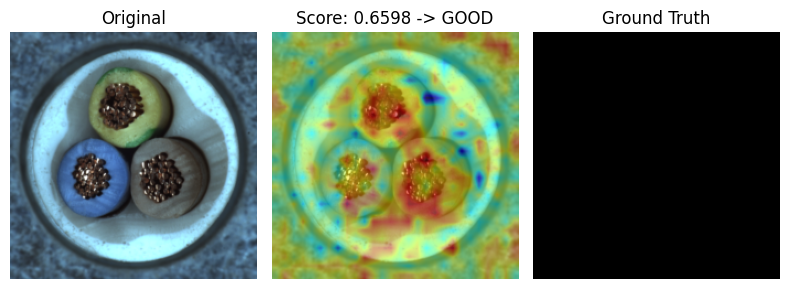

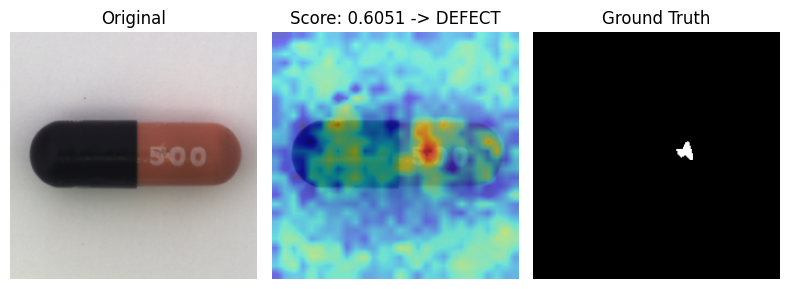

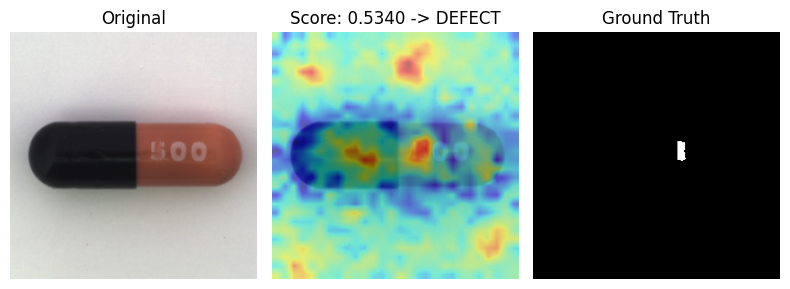

...

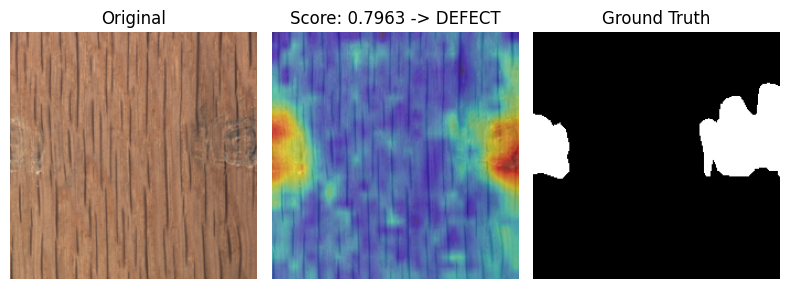

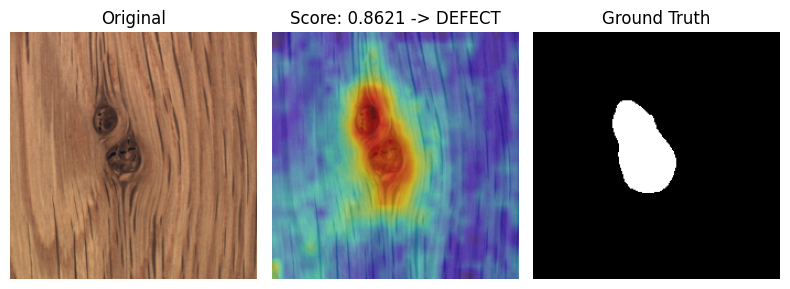

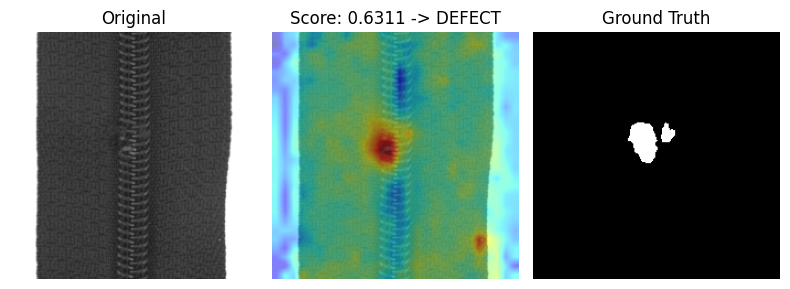

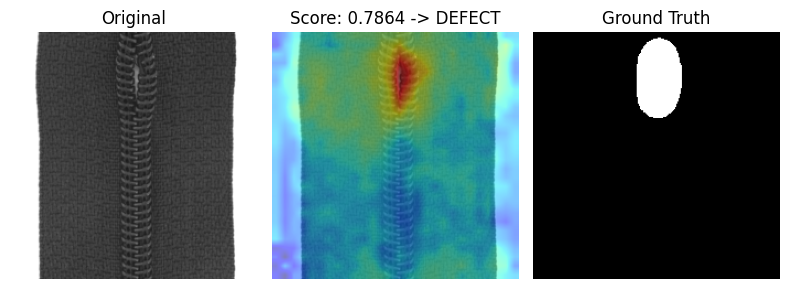

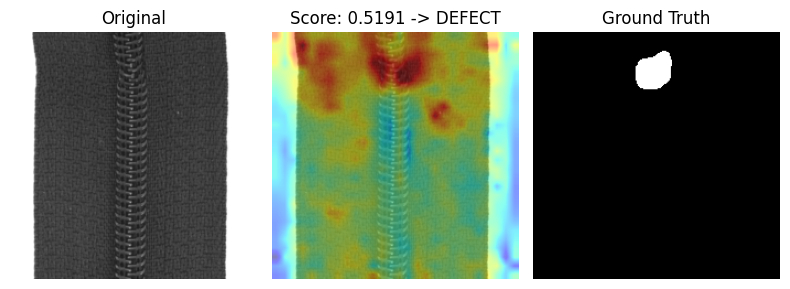

In [18]:
def denormalize(image):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    image = (image.cpu() * std + mean).clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


def show_prediction(image, anomaly_map, gt_mask, score, threshold):
    image_vis = denormalize(image)
    verdict = "DEFECT" if score >= threshold else "GOOD"

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_vis)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(image_vis)
    plt.imshow(anomaly_map, alpha=0.5, cmap="jet")
    plt.title(f"Score: {score:.4f} -> {verdict}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(gt_mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def show_samples_from_checkpoint(category, num_samples=3):
    checkpoint = load_checkpoint(category, device)
    dataset = ImageFolderDataset(DATASET_ROOT / category / "test", transform)

    for idx in np.random.choice(len(dataset), size=num_samples, replace=False):
        image, path = dataset[idx]
        scores, anomaly_maps = predict_batch(
            image.unsqueeze(0), backbone, checkpoint["memory_bank"], device
        )
        gt_mask = get_ground_truth_mask(path, DATASET_ROOT / category / "ground_truth")

        show_prediction(image, anomaly_maps[0].numpy(), gt_mask, scores[0].item(), checkpoint["threshold"])

for i in range(1,15):
    show_samples_from_checkpoint(CATEGORIES[i])